# ⚙️ Pré-processamento e Feature Engineering

Nesta análise:

- Limpeza dos dados
- Tratamento de inconsistências
- Criação das variáveis RFM (Recency, Frequency, Monetary)

O objetivo é gerar uma base pronta para aplicação do modelo de clustering (K-Means).

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
project_root = Path.cwd().parent
data_path = project_root / "data" / "raw" / "customer_segmentation.xlsx"

df = pd.read_excel("../data/raw/customer_segmentation.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
1,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
2,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
3,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
4,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom


In [9]:
df = df.dropna(subset=["CustomerID"])

In [10]:
df = df[df["Quantity"] > 0]

In [11]:
df = df[df["UnitPrice"] > 0]

In [12]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [15]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Data Instantanea:", snapshot_date)

Data Instantanea: 2011-12-10 12:50:00


### Criar RFM

Recency, Frequency, Monetary - Conceitos muito usados em problemas desse tipo 

In [16]:
recency_df = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency_df["Recency"] = (snapshot_date - recency_df["InvoiceDate"]).dt.days

recency_df = recency_df[["CustomerID", "Recency"]]

In [17]:
frequency_df = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()

frequency_df.rename(columns={"InvoiceNo": "Frequency"}, inplace=True)

In [18]:
monetary_df = df.groupby("CustomerID")["TotalPrice"].sum().reset_index()

monetary_df.rename(columns={"TotalPrice": "Monetary"}, inplace=True)

In [19]:
rfm = recency_df.merge(frequency_df, on="CustomerID")
rfm = rfm.merge(monetary_df, on="CustomerID")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,438.92
2,12348.0,319,2,443.52
3,12349.0,19,1,213.64
4,12350.0,310,1,42.90


In [20]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,3953.000000,3953.000000,3953.000000,3953.000000
mean,15276.768783,96.868201,3.586390,318.678680
std,1720.173489,101.264983,6.149387,1756.727134
min,12346.000000,1.000000,1.000000,0.390000
25%,13801.000000,20.000000,1.000000,42.600000
50%,15257.000000,54.000000,2.000000,104.910000
75%,16764.000000,155.000000,4.000000,255.560000
max,18287.000000,374.000000,173.000000,77183.600000


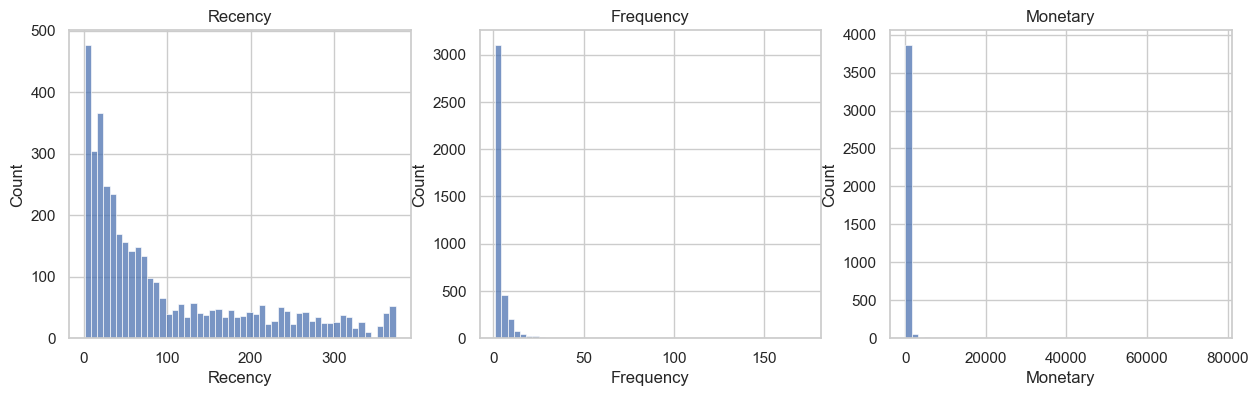

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(rfm["Recency"], bins=50, ax=axes[0])
axes[0].set_title("Recency")

sns.histplot(rfm["Frequency"], bins=50, ax=axes[1])
axes[1].set_title("Frequency")

sns.histplot(rfm["Monetary"], bins=50, ax=axes[2])
axes[2].set_title("Monetary")

plt.show()

In [22]:
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

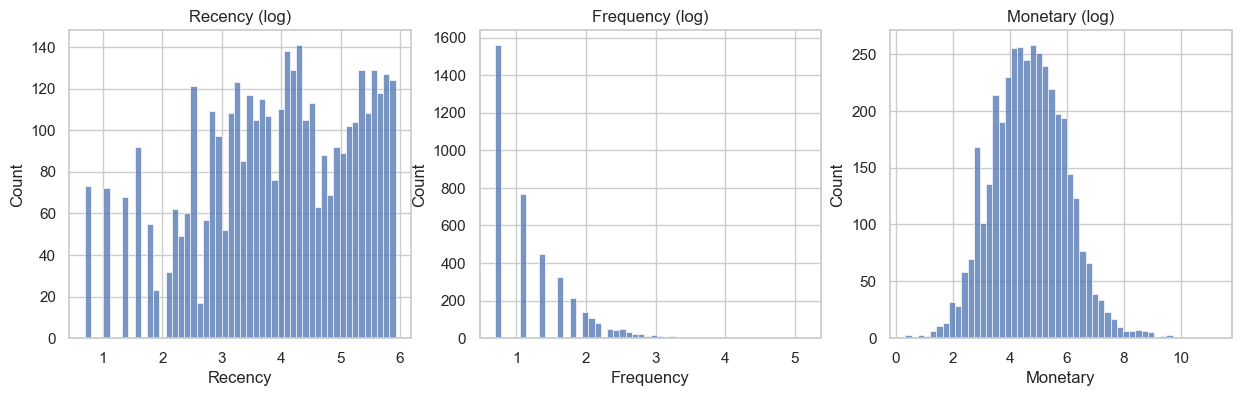

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(rfm_log["Recency"], bins=50, ax=axes[0])
axes[0].set_title("Recency (log)")

sns.histplot(rfm_log["Frequency"], bins=50, ax=axes[1])
axes[1].set_title("Frequency (log)")

sns.histplot(rfm_log["Monetary"], bins=50, ax=axes[2])
axes[2].set_title("Monetary (log)")

plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log[["Recency", "Frequency", "Monetary"]])

rfm_scaled = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])

rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.428752,-0.896860,5.042857
1,-2.129373,1.310373,1.080858
2,1.412340,-0.251286,1.088834
3,-0.690514,-0.896860,0.530626
4,1.390703,-0.896860,-0.686220


In [26]:
output_path = project_root / "data" / "processed" / "processed_dataset.csv"

rfm_scaled.to_csv(output_path, index=False)

## 📌 Insights

- As variáveis apresentam alta assimetria → log transform foi necessário
- Após normalização, os dados estão prontos para K-Means
- Cada cliente agora é representado por 3 dimensões comportamentais (RFM)